In [1]:
import os, sys
#import interface_main, spectrum
from astropy.io import fits
#from collections import namedtuple
import numpy as np
%matplotlib notebook
import matplotlib.pyplot as plt
from ipywidgets import interact
import importlib

#import pandas as pd
#import EW
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
sys.path.insert(0,'../interface/')
import GISIC_C as GISIC


In [3]:
# Get the current working 
# directory (CWD) 
cwd = os.getcwd() 
      
# Print the current working 
# directory (CWD) 
print("Current working directory:", cwd) 

Current working directory: /Users/jyoon/GitHub/CASPER/inspect


In [4]:
%ls ../inputs/spectra/bf-full-survey-data/

Icon?                     jy1706_m1b_casper.fits    jy2866_m1b_casper.fits
g77-61_blue_sum.fits      jy1706_m2b_casper.fits    jy2866_m2b_casper.fits
g77-61_m1b_casper.fits    jy1894_m1b_casper.fits    jy3116_med_casper.fits
g77-61_m2b_casper.fits    jy1894_m2b_casper.fits    jy3116_sum_casper.fits
hd198269_m1b_casper.fits  jy1900_m1b_casper.fits    jy3193_m1b_casper.fits
hd198269_m2b_casper.fits  jy1900_m2b_casper.fits    jy3193_m2b_casper.fits
he0017_m1b_casper.fits    jy1926_m1b_casper.fits    jy3196_med_casper.fits
jy0502_sum_casper.fits    jy1926_m2b_casper.fits    jy3196_sum_casper.fits
jy0538_sum_casper.fits    jy2040_m1b_casper.fits    jy3233_sum_casper.fits
jy0768_med_casper.fits    jy2183_m1b_casper.fits    jy3255_m1b_casper.fits
jy0768_sum_casper.fits    jy2183_m2b_casper.fits    jy3255_m2b_casper.fits
jy0909_m1b_casper.fits    jy2309_med_casper.fits    jy3291_m1b_casper.fits
jy0909_m2b_casper.fits    jy2309_sum_casper.fits    jy3291_m2b_casper.fits
jy1051_m1b_casper.fits   

In [5]:
# Changing the CWD 
#os.chdir('../') 

In [6]:
spectra_path= "../inputs/spectra/bf-full-survey-data/"

In [33]:
star="g77-61"
star_m1b= star+"_m1b_casper.fits"
#star_m1b="smss1738_m1b_casper.fits"
star_m2b= star+"_m2b_casper.fits"
star_comb= star+"_blue_sum.fits"

In [34]:
spec1= fits.open(spectra_path+star_m1b)
spec2= fits.open(spectra_path+star_m1b)
#comb= fits.open(spectra_path+star_comb)

In [35]:
spec1.info()

Filename: ../inputs/spectra/bf-full-survey-data/g77-61_m1b_casper.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     287   (8192, 1, 4)   float32   


In [36]:
spec1[0].header

SIMPLE  =                    T / Fits standard                                  
BITPIX  =                  -32 / Bits per pixel                                 
NAXIS   =                    3 / Number of axes                                 
NAXIS1  =                 8192 / Axis length                                    
NAXIS2  =                    1 / Axis length                                    
NAXIS3  =                    4 / Axis length                                    
EXTEND  =                    F / File may contain extensions                    
ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        
DATE    = '2018-06-27T16:59:05' / Date FITS file was generated                  
IRAF-TLM= '2020-05-13T19:21:53' / Time of last modification                     
OBJECT  = 'g77-61  '           / Name of the object observed                    
BUNIT   = 'ADU     '               / units of physical values (LBT)             
COMMENT  Detector Informatio

In [37]:
spec1[0].data[0]

array([[-250.066   ,  -90.736206,   28.98607 , ...,  914.66797 ,
         964.96826 , 1329.5763  ]], dtype=float32)

In [38]:
spec1[0].data.dtype

dtype('>f4')

In [39]:
spec1[0].data[0].shape

(1, 8192)

In [40]:
spec1[0].data[:,:,3]

array([[38.406013],
       [39.50569 ],
       [62.886402],
       [ 5.072783]], dtype=float32)

In [41]:
spec1[0].header['CRVAL1']
spec1[0].header['CD1_1']

2107.3292840536

0.537480645210701

In [42]:
wave1_unc = (np.arange(0, spec1[0].header['NAXIS1'], 1) * spec1[0].header['CD1_1']) + spec1[0].header['CRVAL1']
flux1 =  spec1[0].data[0].flatten()

In [43]:
#rv1 =  18.4 # jy2866
rv1 =  -10.4 # G77-61

#rv1 = 70 # smss1738
        # Later, I would use astropy constant for speed of light, Sep 02 2020, J. Yoon
wave1 = wave1_unc/((rv1/2.99792e5) + 1)


In [44]:
print(wave1_unc[3000], wave1[3000])


3719.7712196857033 3719.9002657001506


In [45]:
wave_int= wave1[np.where((wave1>3880) &( wave1<4830))]
flux_int= flux1[np.where((wave1>3880) &( wave1<4830))]

In [46]:
plt.plot(wave1, flux1, lw =0.5)
plt.axvline(4320, lw= 0.5,color ='r')
#plt.xlim(4200, 4400)
plt.minorticks_on()

In [47]:
importlib.reload(GISIC)


<module 'GISIC_C' from '../interface/GISIC_C/__init__.py'>

In [48]:
wave1, norm_flux1, continuum1 = GISIC.normalize(wave1, flux1, sigma=30, k=1, 
                                                cahk=True,band_check=True, boost=True)
wave1, norm_flux2, continuum2 = GISIC.normalize(wave1, flux1, sigma=30, k=1, 
                                                cahk=True,band_check=True, boost=False)


	adding CaII H&K continuum points
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
	adding CaII H&K continuum points
GISIC test False
GISIC test False
GISIC test Fal

<IPython.core.display.Javascript object>


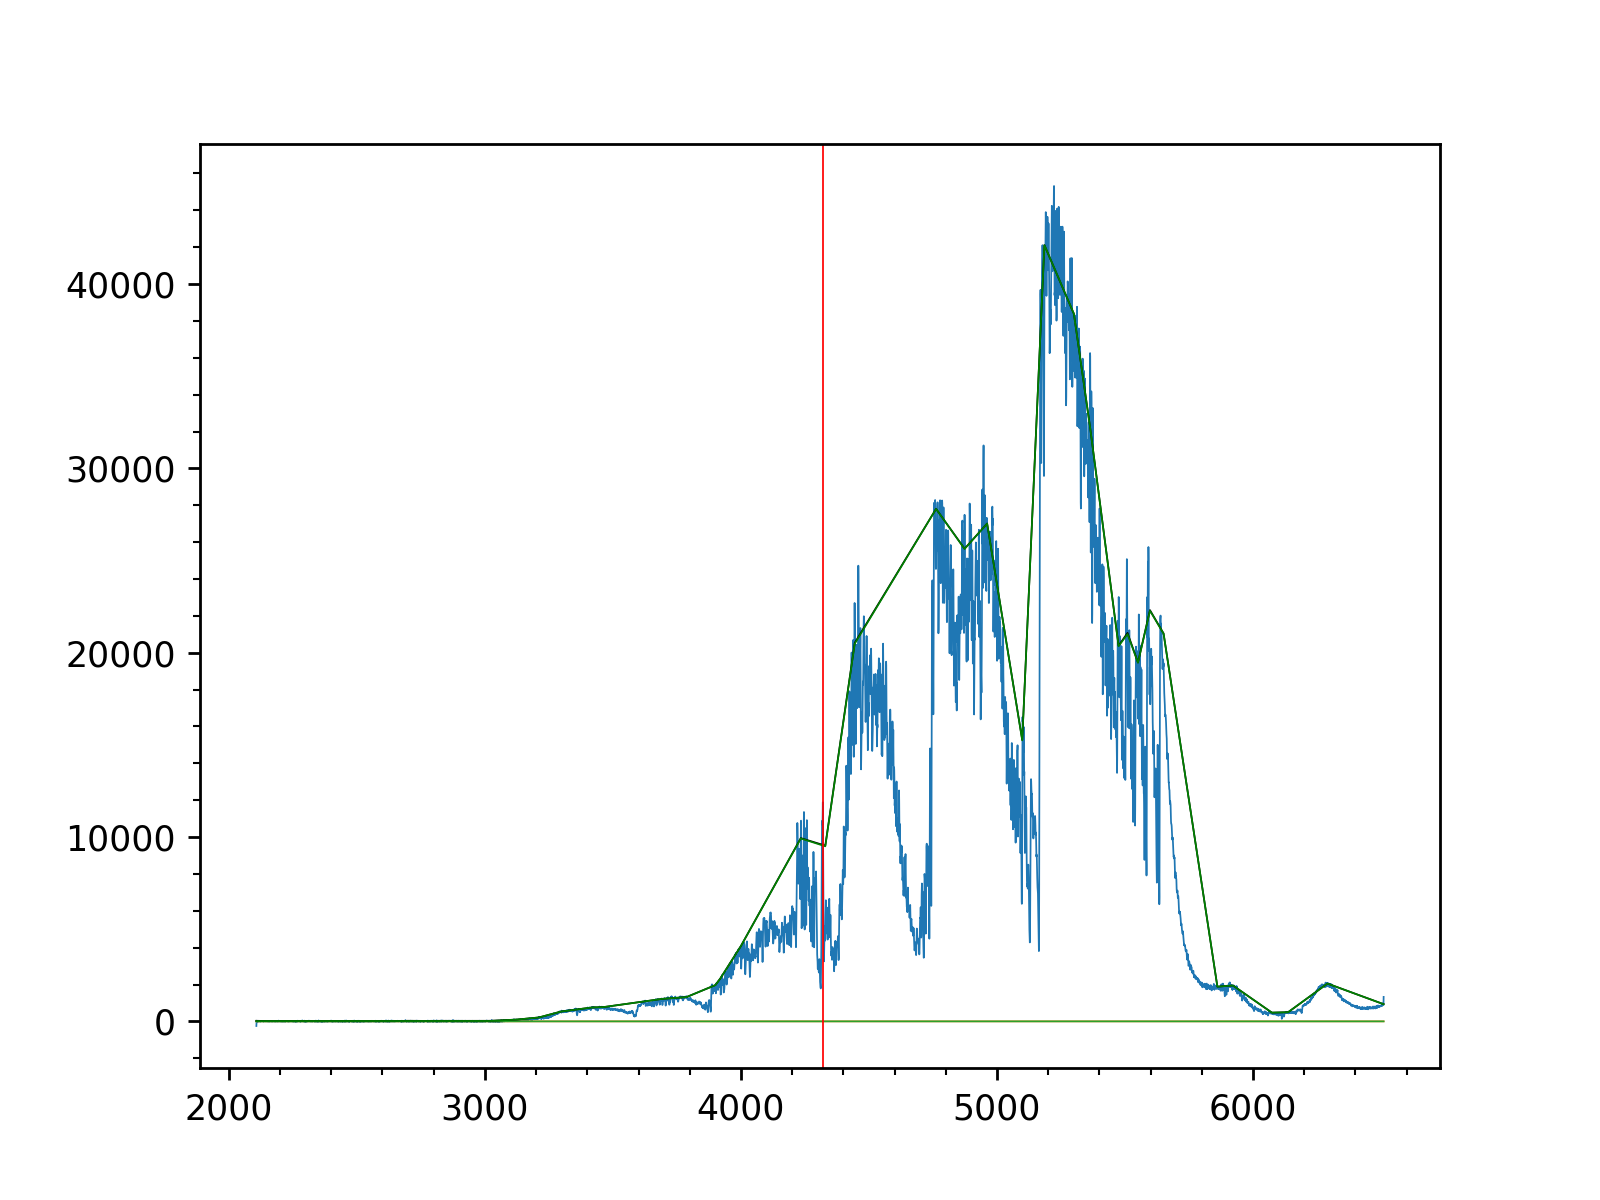

In [50]:
plt.plot(wave1, flux1, lw=0.5)
plt.plot(wave1, norm_flux1, lw=0.5)
plt.plot(wave1, norm_flux2, lw=0.5)
plt.plot(wave1, continuum1, lw=0.5, color='k')
plt.plot(wave1, continuum2, lw=0.5, color='g')
plt.axvline(4320, color ='r', lw=0.5)

plt.minorticks_on()

In [51]:
wave_cut, norm_flux_cut, continuum_cut = GISIC.normalize(wave_int, flux_int, sigma=30,k=1, s=12, cahk=True, 
                                                         band_check=True, flux_min=60, boost=True)
wave_cut, norm_flux_cut2, continuum_cut2 = GISIC.normalize(wave_int, flux_int, sigma=30,k=1, s=12, cahk=True, 
                                                         band_check=True, flux_min=70, boost=True)
wave_cut, norm_flux_cut3, continuum_cut3 = GISIC.normalize(wave_int, flux_int, sigma=30,k=1, s=12, cahk=True, 
                                                         band_check=True, flux_min=80, boost=True)

	adding CaII H&K continuum points
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
	adding CaII H&K continuum points
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
	adding CaII H&K continuum points
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False


<IPython.core.display.Javascript object>


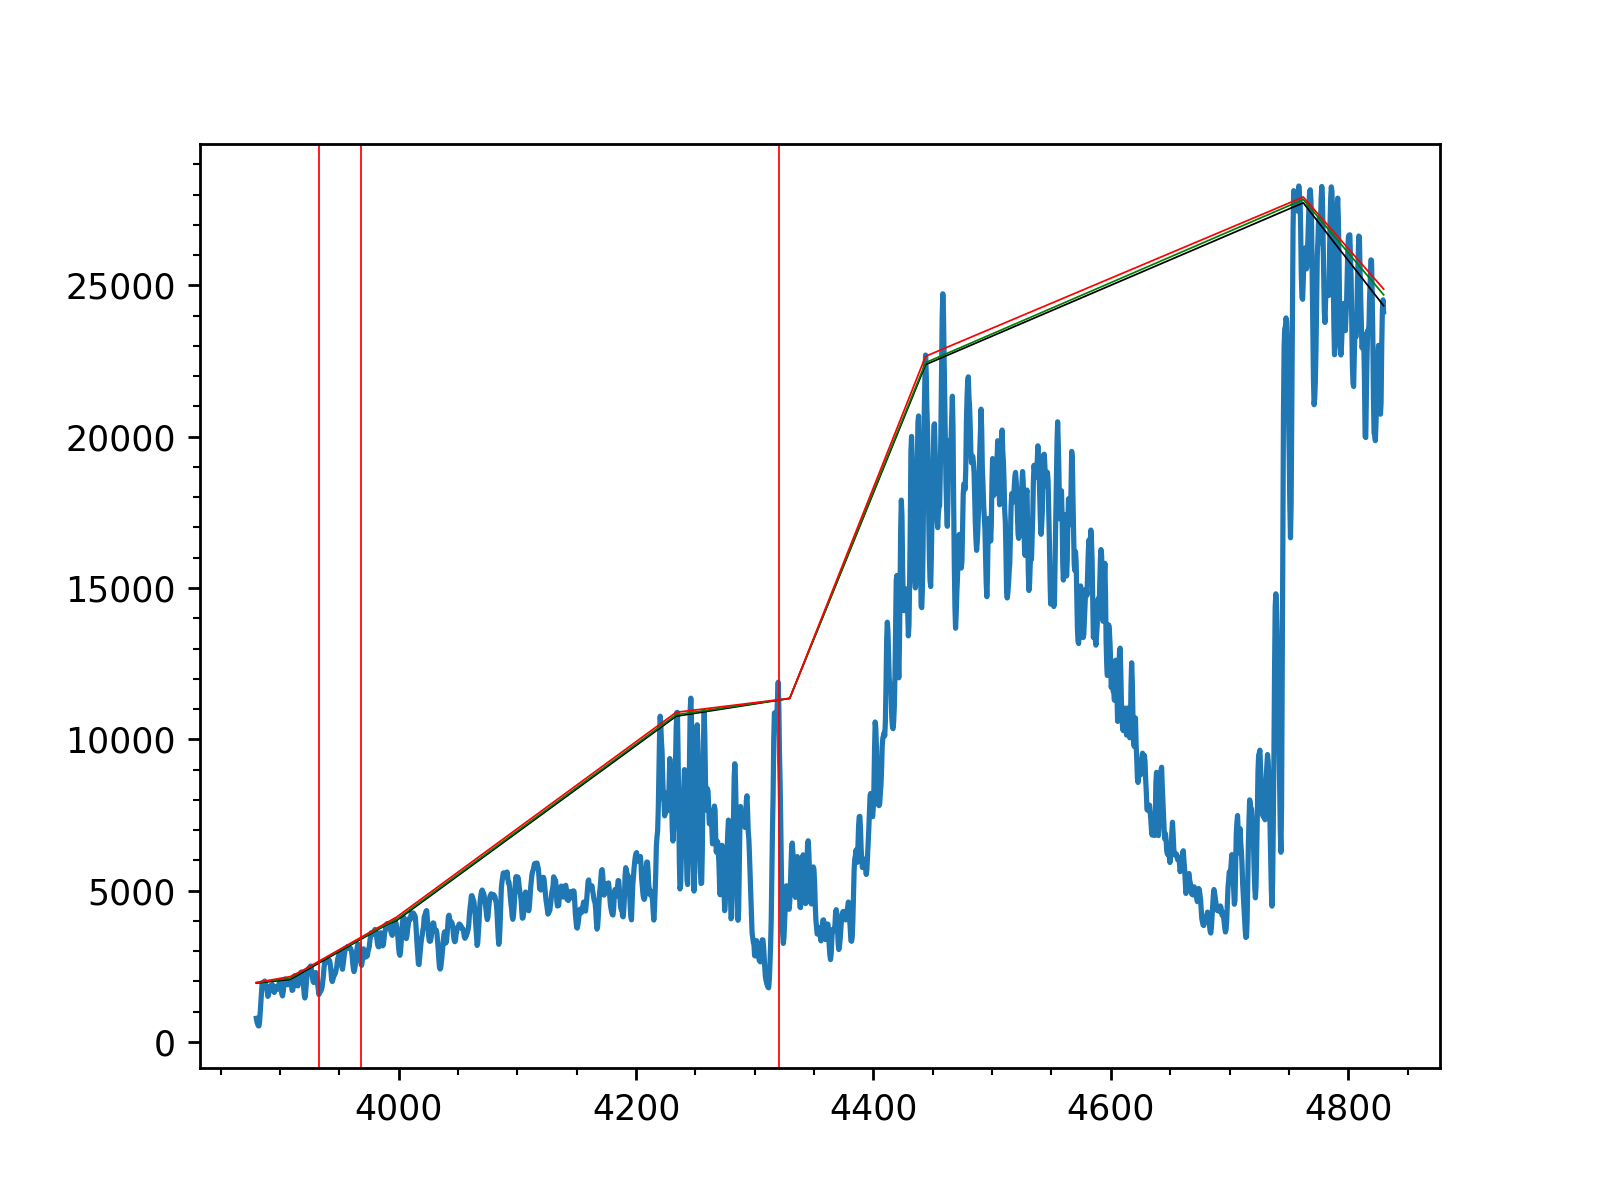

In [53]:
plt.plot(wave_int, flux_int)
plt.plot(wave_cut, continuum_cut, lw=0.5, color='k')
plt.plot(wave_cut, continuum_cut2, lw=0.5, color='g')
plt.plot(wave_cut, continuum_cut3, lw=0.5, color='r')
plt.axvline(3933, color ='r', lw=0.5)
plt.axvline(3968, color ='r', lw=0.5)
plt.axvline(4320, color ='r', lw=0.5)

plt.minorticks_on()

<IPython.core.display.Javascript object>


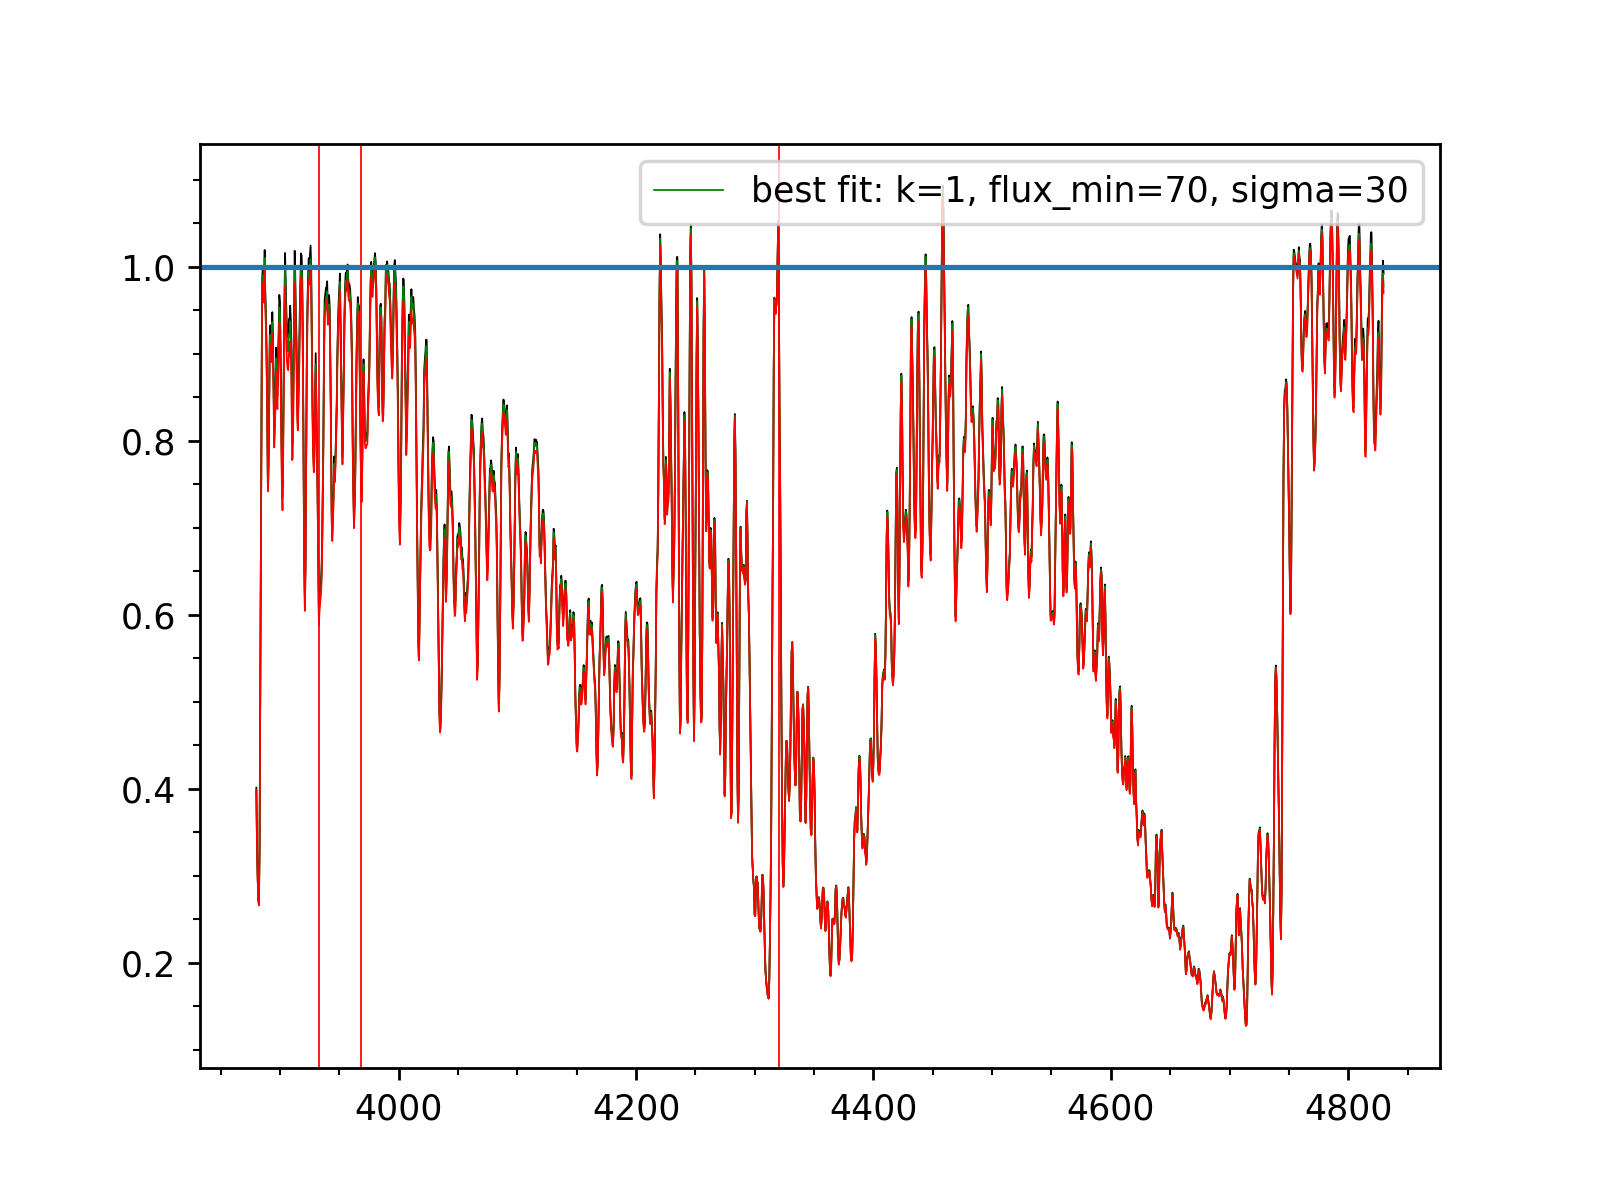

In [54]:
plt.plot(wave_cut, norm_flux_cut, 'k-', lw=0.5)
plt.plot(wave_cut, norm_flux_cut2, 'g-',lw=0.5, label='best fit: k=1, flux_min=70, sigma=30')
plt.plot(wave_cut, norm_flux_cut3,'r-', lw=0.5)
plt.axvline(3933, color ='r', lw=0.5)
plt.axvline(3968, color ='r', lw=0.5)
plt.axvline(4320, color ='r', lw=0.5)
plt.axhline (1)
plt.legend(loc=1)
plt.minorticks_on()

In [55]:
wave_cut, norm_flux_cut, continuum_cut = GISIC.normalize(wave_int, flux_int, sigma=30,k=1, s=12, cahk=True, 
                                                         band_check=True, flux_min=70, boost=True)
wave_cut, norm_flux_cut2, continuum_cut2 = GISIC.normalize(wave_int, flux_int, sigma=40,k=1, s=12, cahk=True, 
                                                         band_check=True, flux_min=70, boost=True)
wave_cut, norm_flux_cut3, continuum_cut3 = GISIC.normalize(wave_int, flux_int, sigma=50,k=1, s=12, cahk=True, 
                                                         band_check=True, flux_min=70, boost=True)

	adding CaII H&K continuum points
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
	adding CaII H&K continuum points
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
	adding CaII H&K continuum points
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False
GISIC test False


<IPython.core.display.Javascript object>


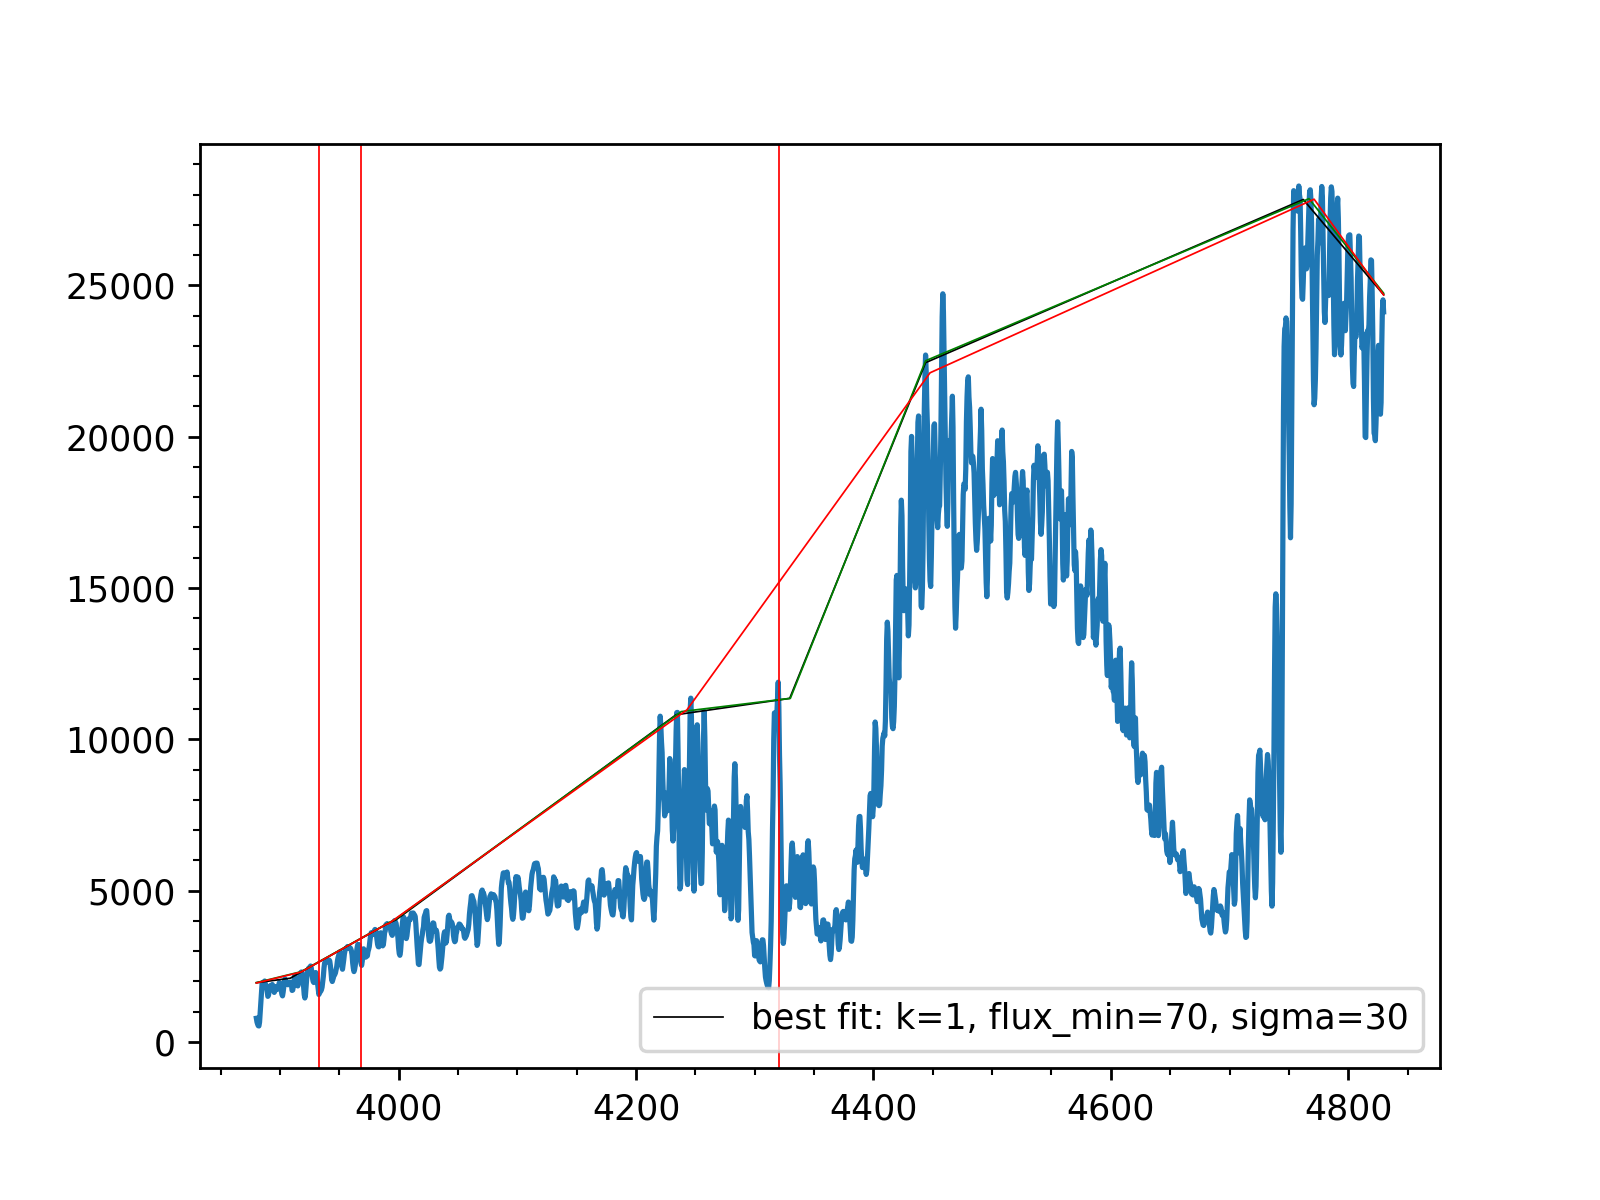

In [56]:
plt.plot(wave_int, flux_int)
plt.plot(wave_cut, continuum_cut, lw=0.5, color='k', label='best fit: k=1, flux_min=70, sigma=30')
plt.plot(wave_cut, continuum_cut2, lw=0.5, color='g')
plt.plot(wave_cut, continuum_cut3, lw=0.5, color='r')
plt.axvline(3933, color ='r', lw=0.5)
plt.axvline(3968, color ='r', lw=0.5)
plt.axvline(4320, color ='r', lw=0.5)
plt.legend()
plt.minorticks_on()

<IPython.core.display.Javascript object>


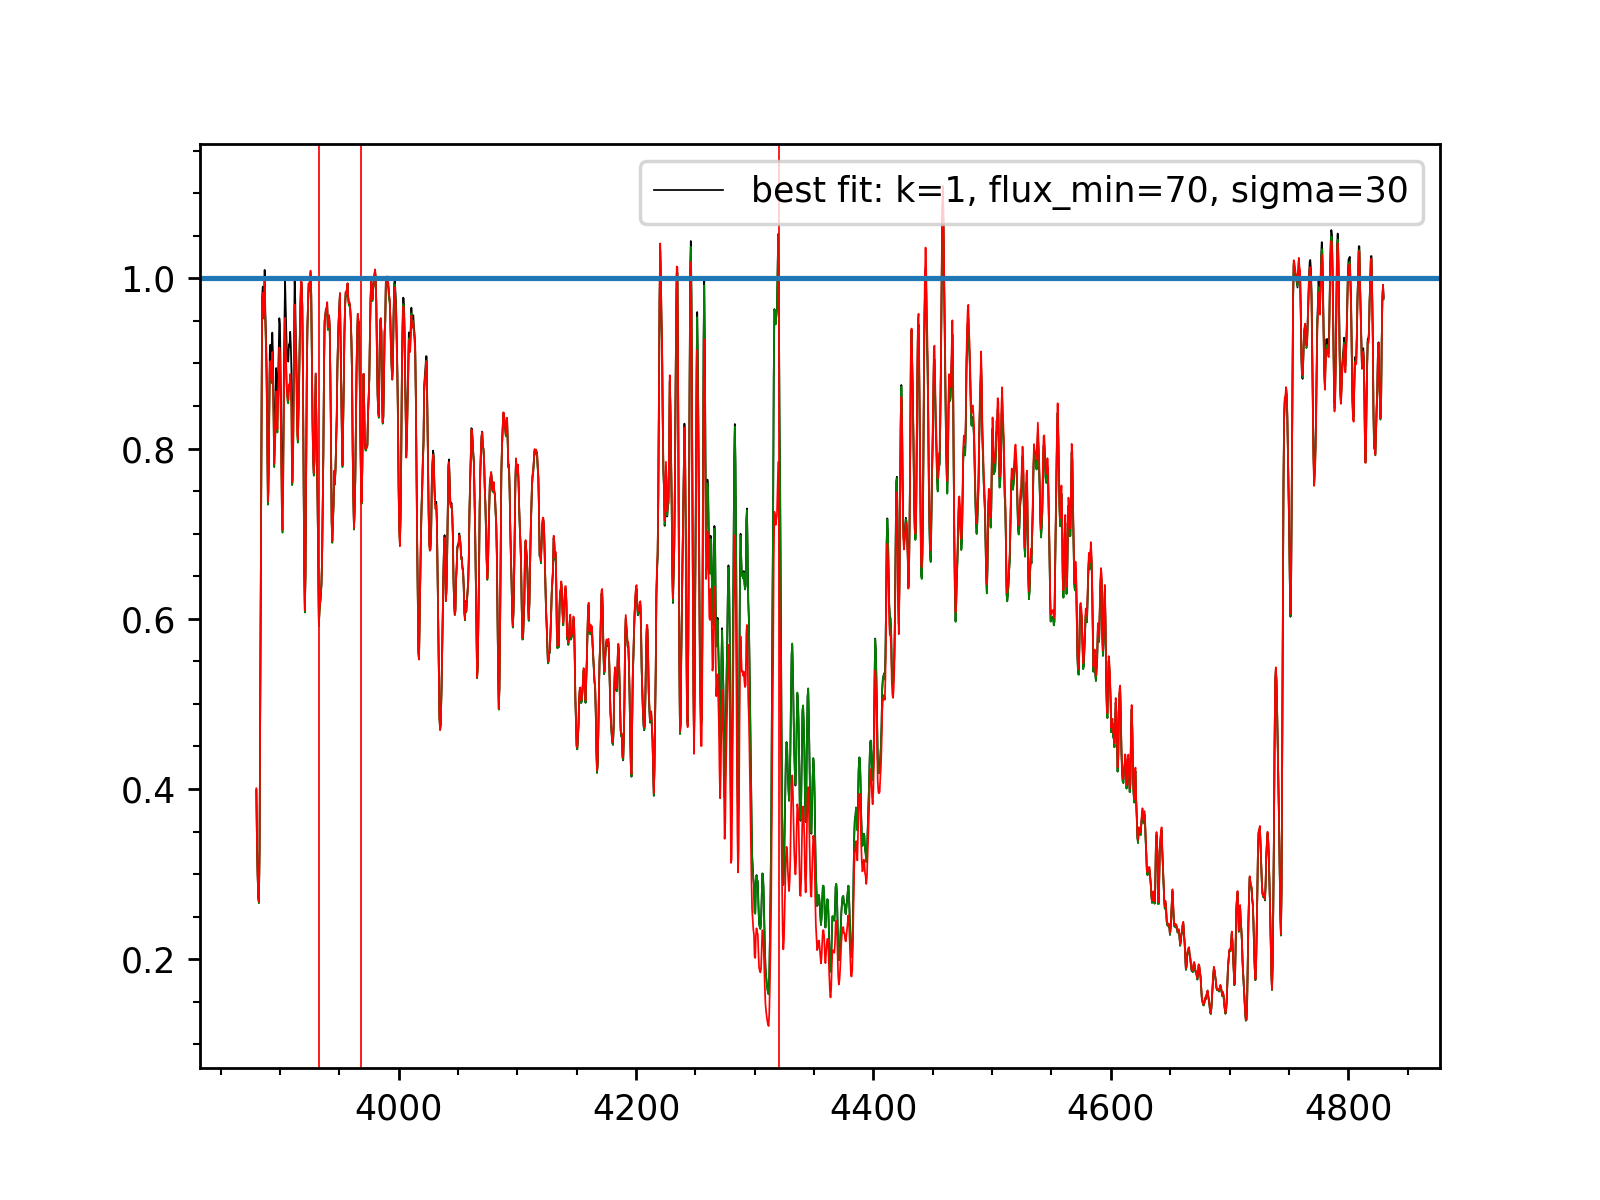

In [57]:
plt.plot(wave_cut, norm_flux_cut, 'k-', lw=0.5,label='best fit: k=1, flux_min=70, sigma=30')
plt.plot(wave_cut, norm_flux_cut2, 'g-',lw=0.5)
plt.plot(wave_cut, norm_flux_cut3,'r-', lw=0.5)
plt.axvline(3933, color ='r', lw=0.5)
plt.axvline(3968, color ='r', lw=0.5)
plt.axvline(4320, color ='r', lw=0.5)
plt.axhline (1)
plt.legend(loc=1)
plt.minorticks_on()

In [58]:
wave_cut, norm_flux_cut, continuum_cut = GISIC.normalize(wave_int, flux_int, sigma=30,k=1, s=12, cahk=True, 
                                                         band_check=False, flux_min=70, boost=True)
wave_cut, norm_flux_cut2, continuum_cut2 = GISIC.normalize(wave_int, flux_int, sigma=30,k=1, s=12, cahk=True, 
                                                         band_check=False, flux_min=70, boost=False)


	adding CaII H&K continuum points
	adding CaII H&K continuum points


<IPython.core.display.Javascript object>


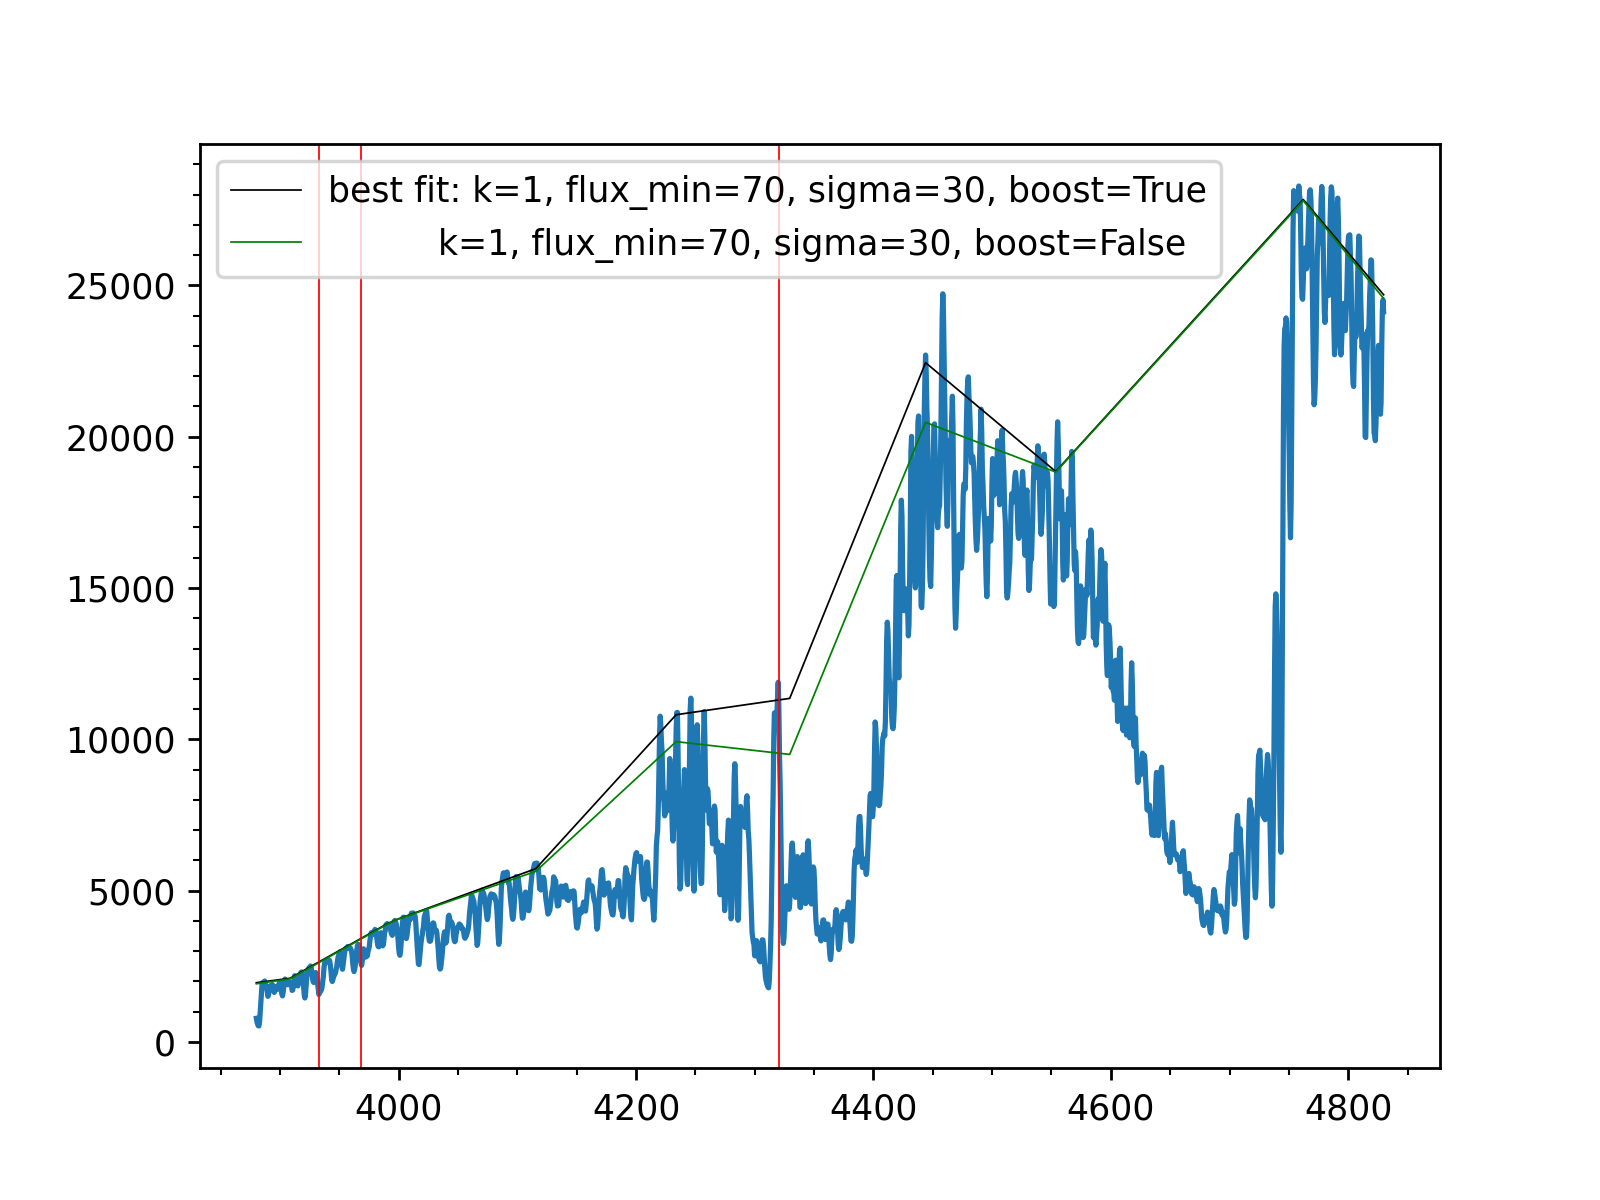

In [59]:
plt.plot(wave_int, flux_int)
plt.plot(wave_cut, continuum_cut, lw=0.5, color='k', label='best fit: k=1, flux_min=70, sigma=30, boost=True')
plt.plot(wave_cut, continuum_cut2, lw=0.5, color='g',label='          k=1, flux_min=70, sigma=30, boost=False')
plt.axvline(3933, color ='r', lw=0.5)
plt.axvline(3968, color ='r', lw=0.5)
plt.axvline(4320, color ='r', lw=0.5)
plt.legend()
plt.minorticks_on()